### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [4]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 8, 'total_tokens': 18, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_6dd05565ef', 'finish_reason': 'stop', 'logprobs': None}, id='run-4f0d271e-b2b4-4d43-b8f1-f724acd1dc71-0', usage_metadata={'input_tokens': 8, 'output_tokens': 10, 'total_tokens': 18, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [5]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="qwen/qwen3-32b")
llm_groq.invoke("Hey I am Krish and i like to play cricket")

AIMessage(content="<think>\nOkay, let's see. The user is Krish and he likes to play cricket. I need to respond appropriately. First, I should acknowledge his name and his interest. Maybe ask him about his favorite team or position in cricket. But wait, I should make sure to keep the conversation open-ended so he can talk more. Also, I should check if he's looking for advice, tips, or just general conversation. Maybe mention some famous cricketers or recent matches if that's relevant. I should keep it friendly and engaging. Let me structure a response that invites him to share more about his experience with cricket.\n</think>\n\nHi Krish! 🏏 That's awesome—you're in for a treat with the exciting world of cricket! Do you play any specific role on the field (batsman, bowler, all-rounder)? I'd love to hear what you enjoy most about the game! Want to chat about techniques, famous matches, or even your favorite players?", additional_kwargs={}, response_metadata={'token_usage': {'completion_to

### We Will start With Creating Nodes

In [6]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

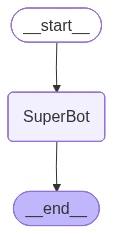

In [7]:
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is VaibhaV And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is VaibhaV And I like cricket', additional_kwargs={}, response_metadata={}, id='b9729f2e-b50b-48d2-a165-ba17c6b4cd2f'),
  AIMessage(content="<think>\nOkay, the user's name is Vaibhav and he likes cricket. Let me start by acknowledging his name and expressing enthusiasm about his interest in cricket. I should keep the response friendly and open-ended to encourage further conversation. Maybe ask him about his favorite team or player. Also, since he might be a fellow cricket fan, I can mention some recent matches or players to connect. Need to make sure the tone is positive and engaging. Let me check for any typos or errors. Alright, that should cover it.\n</think>\n\nHello, Vaibhav! 🏏 It's great to meet another cricket enthusiast! I'd love to hear more about your favorite teams, players, or even your dream of playing the game. What got you into cricket, and who are your favorite players? Let's chat about the sport!", additional_kwargs={}, re

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

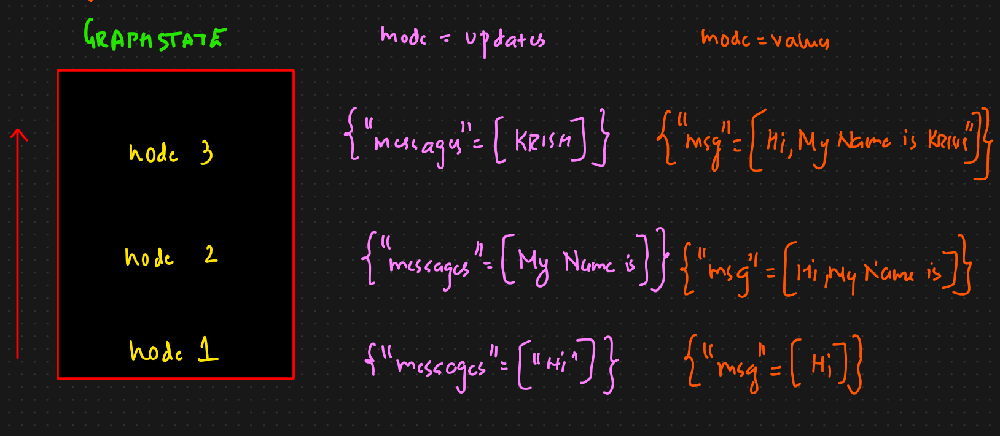

#### Streaming The Responses With Stream Method

In [9]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Vaibhav And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user is Vaibhav and he likes cricket. He just said hello and introduced himself. I should respond in a friendly and welcoming way. Maybe ask him about his favorite team or a memorable cricket moment. Keep it light and engaging. Let him know I'm here to chat about cricket or anything else he's interested in. Make sure the tone is positive and approachable. Avoid any technical jargon unless he brings it up. Keep the response concise but warm. Alright, let's put that together.\n</think>\n\nHi Vaibhav! Nice to meet you! 🏏 Since you like cricket, let me ask—do you have a favorite team or player? Also, what’s one of your most exciting cricket memories (whether watching or playing)? I’d love to hear your take!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 167, 'prompt_tokens': 21, 'total_tokens': 188, 'completion_time': 0.387967259, 'completion_tokens_details': None, 'prompt_time': 0.000762434, 

In [10]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Vaibhav And I like cricket', additional_kwargs={}, response_metadata={}, id='ce839c87-0930-401e-b5b9-0fb51e897035'), AIMessage(content="<think>\nOkay, the user is Vaibhav and he likes cricket. He just said hello and introduced himself. I should respond in a friendly and welcoming way. Maybe ask him about his favorite team or a memorable cricket moment. Keep it light and engaging. Let him know I'm here to chat about cricket or anything else he's interested in. Make sure the tone is positive and approachable. Avoid any technical jargon unless he brings it up. Keep the response concise but warm. Alright, let's put that together.\n</think>\n\nHi Vaibhav! Nice to meet you! 🏏 Since you like cricket, let me ask—do you have a favorite team or player? Also, what’s one of your most exciting cricket memories (whether watching or playing)? I’d love to hear your take!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16

In [12]:
for chunk in graph_builder.stream({'messages':"I also like football "},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='<think>\nOkay, the user has mentioned they like both cricket and football a few times now. I need to make sure I don\'t miss any key points here. Let me check the conversation history.\n\nFirst, the user introduced themselves as Vaibhav and mentioned liking cricket. I asked about their favorite team and memories. Then they said they also like football, and I asked which they enjoy more or if they follow any leagues. They responded again saying they like football, so maybe they just want to elaborate more on that. \n\nHmm, the user might be emphasizing their interest in football. Maybe they want to talk more about it. Let me see. In the previous messages, they repeated "I also like football" twice after I asked about leagues and teams. That could be a sign that they want to expand on their football preferences. Perhaps they need more prompting to share specific details.\n\nI should ask more specific questions to get them to open up. Maybe ab

In [13]:
for chunk in graph_builder.stream({'messages':"I Love sports "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Vaibhav And I like cricket', additional_kwargs={}, response_metadata={}, id='ce839c87-0930-401e-b5b9-0fb51e897035'), AIMessage(content="<think>\nOkay, the user is Vaibhav and he likes cricket. He just said hello and introduced himself. I should respond in a friendly and welcoming way. Maybe ask him about his favorite team or a memorable cricket moment. Keep it light and engaging. Let him know I'm here to chat about cricket or anything else he's interested in. Make sure the tone is positive and approachable. Avoid any technical jargon unless he brings it up. Keep the response concise but warm. Alright, let's put that together.\n</think>\n\nHi Vaibhav! Nice to meet you! 🏏 Since you like cricket, let me ask—do you have a favorite team or player? Also, what’s one of your most exciting cricket memories (whether watching or playing)? I’d love to hear your take!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 16

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [14]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Vaibhav and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Vaibhav and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019e3ab1-6d06-7651-ae41-eafaefc047d4', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Vaibhav And I like cricket', additional_kwargs={}, response_metadata={}, id='ce839c87-0930-401e-b5b9-0fb51e897035'), AIMessage(content="<think>\nOkay, the user is Vaibhav and he likes cricket. He just said hello and introduced himself. I should respond in a friendly and welcoming way. Maybe ask him about his favorite team or a memorable cricket moment. Keep it light and engaging. Let him know I'm here to chat about cricket or anything else he's interested in. Make sure the tone is positive and approachable. Avoid any technical jargon unless he brings it up. Keep the response concise but warm. Alright, let's put that t